# Other-religion open-ended response categories, 2025

This notebook rebuilds the religion open-ended response CSVs and bar charts from `cfsrALL.csv`. The response category tags are embedded below because those classifications are manually curated and cannot be inferred from the raw data alone.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

DATA_PATH = Path("cfsrALL.csv")
YEAR = 2025

OUT_RAW_TAGGED = Path("other_religion_open_ended_raw_by_gender_2025_tagged.csv")
OUT_COUNTS_TAGGED = Path("other_religion_open_ended_counts_by_gender_2025_tagged.csv")
OUT_TAG_TOLERANCE = Path("other_religion_tag_tolerance_by_gender_2025.csv")
OUT_OVERALL_TOLERANCE = Path("overall_tolerance_by_gender_2025.csv")
OUT_LONG_JOKE = Path("long_and_joke_religion_responses_tolerance_by_gender_2025.csv")

GENDER_LABELS = {1: "Men", 2: "Women", 3: "Nonbinary"}
GENDER_ORDER = ["Men", "Women", "Nonbinary"]
PLOT_GENDER_ORDER = ["Men", "Women"]

SEX_ORIENTATION_LABELS = {
    1: "Straight (Heterosexual)",
    2: "Gay/Lesbian",
    3: "Bisexual",
    4: "Queer/Questioning/Other",
    98: "Not in survey",
    99: "Missing",
}
SEX_ORIENTATION_ORDER = [1, 2, 3, 4, 98, 99]

TAG_ORDER = [
    "Normal",
    "Unusual",
    "Short explanation",
    "Long explanation",
    "Joke",
    "Other",
]
TAG_COLORS = {
    "Normal": "#4C78A8",
    "Unusual": "#F58518",
    "Short explanation": "#54A24B",
    "Long explanation": "#E45756",
    "Joke": "#72B7B2",
    "Other": "#79706E",
}

RIGHT_TRIAD = ["spk_abortion", "spk_trans", "spk_blm"]
LEFT_TRIAD = ["spk_cathped", "spk_policekkk", "spk_kidtrans"]
SPK_COLS = RIGHT_TRIAD + LEFT_TRIAD

PLOT_SPECS = [
    ("average_tolerance", "Average tolerance"),
    ("minimum_tolerance", "Minimum tolerance"),
    ("average_tolerance_ideoadj", "Ideology-controlled average tolerance"),
    ("minimum_tolerance_ideoadj", "Ideology-controlled minimum tolerance"),
]

CREDIT_TEXT = (
    "Chart: Chapin Lenthall-Cleary\n"
    "Source: FIRE's 2026 College Free Speech Rankings Survey (2025 data)"
)
CREDIT_COLOR = "#4b5563"

TAG_LOOKUP_RECORDS = [{'Response': '.', 'Tag': 'Other'}, {'Response': '3, 6, 9', 'Tag': 'Joke'}, {'Response': '7th day Adventist Christian', 'Tag': 'Normal'}, {'Response': 'ATR', 'Tag': 'Unusual'}, {'Response': 'Adventist', 'Tag': 'Normal'}, {'Response': 'Agnostic Atheist', 'Tag': 'Normal'}, {'Response': 'Agnostic atheist', 'Tag': 'Normal'}, {'Response': 'Agnostic atheist (don’t possess a belief in any gods but don’t claim to know for sure whether they exist)', 'Tag': 'Long explanation'}, {'Response': 'Agnostic but looking into Christianity', 'Tag': 'Short explanation'}, {'Response': 'Agnostic spiritually, Jewish culturally', 'Tag': 'Short explanation'}, {'Response': 'Agnostic theist', 'Tag': 'Normal'}, {'Response': 'Agnostic: I believe that there’s some higher power out there but there is no evidence of what it is.', 'Tag': 'Long explanation'}, {'Response': 'Agnostics do believe in a higher power', 'Tag': 'Short explanation'}, {'Response': 'All of the above, believe in every religion', 'Tag': 'Joke'}, {'Response': 'Amari', 'Tag': 'Joke'}, {'Response': 'Anabaptist', 'Tag': 'Normal'}, {'Response': 'And buddhist', 'Tag': 'Normal'}, {'Response': 'Anglican', 'Tag': 'Normal'}, {'Response': 'Anglican. Common mistake that there is an assumed binary between Catholic and Protestant (Anglican is neither)', 'Tag': 'Long explanation'}, {'Response': 'Animism', 'Tag': 'Unusual'}, {'Response': 'Animism + open to any possibility', 'Tag': 'Short explanation'}, {'Response': 'Apostolic', 'Tag': 'Normal'}, {'Response': 'Apostolic Pentecostal', 'Tag': 'Normal'}, {'Response': 'Armenian Apostolic', 'Tag': 'Normal'}, {'Response': 'Assemblies of God', 'Tag': 'Normal'}, {'Response': 'Atheist. Does metamodernism count?', 'Tag': 'Joke'}, {'Response': 'Athiest, Jewish', 'Tag': 'Short explanation'}, {'Response': 'Bahai', 'Tag': 'Normal'}, {'Response': 'Bahaii', 'Tag': 'Normal'}, {'Response': 'Baha’i', 'Tag': 'Normal'}, {'Response': 'Bahá’í', 'Tag': 'Normal'}, {'Response': 'Baptist', 'Tag': 'Normal'}, {'Response': 'Baptist Christian', 'Tag': 'Normal'}, {'Response': 'Baptist/ Pentecostal', 'Tag': 'Short explanation'}, {'Response': 'Baseball Gods', 'Tag': 'Joke'}, {'Response': 'Belief in a god', 'Tag': 'Short explanation'}, {'Response': 'Believe in All', 'Tag': 'Joke'}, {'Response': 'Believe in God', 'Tag': 'Short explanation'}, {'Response': "Believe in God, don't subscribe to a specific religion. But certainly not Athiest or Agnostic", 'Tag': 'Long explanation'}, {'Response': 'Believe in God, no particular religion', 'Tag': 'Short explanation'}, {'Response': 'Believe in Jesus', 'Tag': 'Short explanation'}, {'Response': 'Believe in a Higher Being but not religious', 'Tag': 'Short explanation'}, {'Response': 'Believe in god but not christian', 'Tag': 'Short explanation'}, {'Response': 'Believer', 'Tag': 'Normal'}, {'Response': 'Believer in God', 'Tag': 'Normal'}, {'Response': 'Bi-ritual Catholic (Roman and Byzantine)', 'Tag': 'Short explanation'}, {'Response': 'Both Buddhist and Christian', 'Tag': 'Short explanation'}, {'Response': 'Both Jewish and Protestant (interfaith)', 'Tag': 'Short explanation'}, {'Response': 'Brazilian Catholic', 'Tag': 'Normal'}, {'Response': 'Buddhist/Agnostic', 'Tag': 'Short explanation'}, {'Response': 'Byzantine Catholic', 'Tag': 'Normal'}, {'Response': 'CHRIST IS KING', 'Tag': 'Joke'}, {'Response': 'COGIC', 'Tag': 'Normal'}, {'Response': 'Candomblé', 'Tag': 'Normal'}, {'Response': 'Catholic', 'Tag': 'Normal'}, {'Response': 'Catholic / Christian', 'Tag': 'Short explanation'}, {'Response': 'Catholic Hindu', 'Tag': 'Normal'}, {'Response': 'Catholic and Christian', 'Tag': 'Short explanation'}, {'Response': 'Catholic and Vietnamese Buddhism Cult', 'Tag': 'Joke'}, {'Response': 'Catholic-ish', 'Tag': 'Normal'}, {'Response': 'Catholic/Agnostic', 'Tag': 'Short explanation'}, {'Response': 'Catholicism', 'Tag': 'Normal'}, {'Response': 'Celtic Pegan', 'Tag': 'Unusual'}, {'Response': 'Child of God', 'Tag': 'Normal'}, {'Response': 'Chinese', 'Tag': 'Other'}, {'Response': 'Christ follower', 'Tag': 'Normal'}, {'Response': 'Christ is King', 'Tag': 'Joke'}, {'Response': 'Christain', 'Tag': 'Normal'}, {'Response': 'Christian', 'Tag': 'Normal'}, {'Response': 'Christian (Lutheran)', 'Tag': 'Short explanation'}, {'Response': 'Christian Baptist', 'Tag': 'Normal'}, {'Response': 'Christian C.O.G.I.C', 'Tag': 'Normal'}, {'Response': 'Christian Catholic', 'Tag': 'Normal'}, {'Response': 'Christian and Jewish', 'Tag': 'Short explanation'}, {'Response': 'Christian and catholic', 'Tag': 'Short explanation'}, {'Response': 'Christian beliefs', 'Tag': 'Normal'}, {'Response': 'Christian practicing', 'Tag': 'Short explanation'}, {'Response': 'Christian!', 'Tag': 'Joke'}, {'Response': 'Christianity', 'Tag': 'Normal'}, {'Response': 'Christianity (but actually living what the Bible teaches)', 'Tag': 'Long explanation'}, {'Response': 'Christian… not “Just” Christian', 'Tag': 'Normal'}, {'Response': 'Church of Christ', 'Tag': 'Normal'}, {'Response': 'Complex', 'Tag': 'Other'}, {'Response': 'Coptic Orthodox Christian', 'Tag': 'Normal'}, {'Response': 'Coptic orthodox', 'Tag': 'Normal'}, {'Response': 'Coptic orthodox Christian', 'Tag': 'Normal'}, {'Response': "Couldn't care either way", 'Tag': 'Other'}, {'Response': 'Creator', 'Tag': 'Unusual'}, {'Response': 'Culturally Jewish, Religiously atheist', 'Tag': 'Short explanation'}, {'Response': 'Daoist', 'Tag': 'Normal'}, {'Response': 'Deism', 'Tag': 'Unusual'}, {'Response': 'Deist', 'Tag': 'Unusual'}, {'Response': 'Deist (there is an Absent God)', 'Tag': 'Short explanation'}, {'Response': 'Different', 'Tag': 'Other'}, {'Response': 'Disciple of Christ', 'Tag': 'Normal'}, {'Response': 'Disciple of Cthulu', 'Tag': 'Joke'}, {'Response': 'Do not believe in milarchy', 'Tag': 'Joke'}, {'Response': "Don't do religion as that's slavery to control the masses... I have a soul and into high level spiritualism and metaphysics.", 'Tag': 'Long explanation'}, {'Response': 'Dont want to say', 'Tag': 'Other'}, {'Response': 'Druid', 'Tag': 'Unusual'}, {'Response': 'Druze', 'Tag': 'Normal'}, {'Response': 'ELCA Lutheran', 'Tag': 'Normal'}, {'Response': 'Eclectic', 'Tag': 'Unusual'}, {'Response': 'Eclectic Pagan', 'Tag': 'Unusual'}, {'Response': 'Energy', 'Tag': 'Unusual'}, {'Response': 'Episcopal', 'Tag': 'Normal'}, {'Response': 'Episcopal Catholic', 'Tag': 'Normal'}, {'Response': 'Episcopal Christian', 'Tag': 'Normal'}, {'Response': 'Episcopalean', 'Tag': 'Normal'}, {'Response': 'Episcopalian', 'Tag': 'Normal'}, {'Response': 'Espiritualismo Trinitario Mariano', 'Tag': 'Normal'}, {'Response': 'Evangelical', 'Tag': 'Normal'}, {'Response': 'Everything', 'Tag': 'Joke'}, {'Response': 'Existentialism', 'Tag': 'Unusual'}, {'Response': 'Existentialist/animist', 'Tag': 'Short explanation'}, {'Response': 'Exploring (primarily Christianity)', 'Tag': 'Short explanation'}, {'Response': 'Figuring it out but believe in god', 'Tag': 'Short explanation'}, {'Response': 'Follow a higher power', 'Tag': 'Short explanation'}, {'Response': 'Follower of Jesus Christ', 'Tag': 'Normal'}, {'Response': 'Former Christian', 'Tag': 'Short explanation'}, {'Response': 'Free Will Baptist', 'Tag': 'Normal'}, {'Response': 'Fuck off', 'Tag': 'Joke'}, {'Response': 'Gaea', 'Tag': 'Unusual'}, {'Response': 'General belief in God', 'Tag': 'Short explanation'}, {'Response': 'Global Methodist', 'Tag': 'Normal'}, {'Response': 'Gnostic', 'Tag': 'Normal'}, {'Response': 'God', 'Tag': 'Normal'}, {'Response': 'God exist', 'Tag': 'Normal'}, {'Response': 'God-Believer', 'Tag': 'Normal'}, {'Response': 'Greek Catholic Christian', 'Tag': 'Normal'}, {'Response': 'Greek Orthodox', 'Tag': 'Normal'}, {'Response': 'Greek/Roman gods', 'Tag': 'Unusual'}, {'Response': 'Grew up catholic and no longer religious', 'Tag': 'Long explanation'}, {'Response': 'Half Catholic Half Jewish', 'Tag': 'Short explanation'}, {'Response': 'Half christian half jewish', 'Tag': 'Short explanation'}, {'Response': 'Heathen', 'Tag': 'Unusual'}, {'Response': 'Hebrew Israelite', 'Tag': 'Normal'}, {'Response': 'Hellenic Pagan', 'Tag': 'Unusual'}, {'Response': 'Hellenic Polytheist', 'Tag': 'Unusual'}, {'Response': 'Hellenist', 'Tag': 'Unusual'}, {'Response': 'Hellenistic Pagan', 'Tag': 'Unusual'}, {'Response': 'Hindu', 'Tag': 'Normal'}, {'Response': 'Hindu & Jewish', 'Tag': 'Short explanation'}, {'Response': 'Hindu and Orthodox Christian', 'Tag': 'Short explanation'}, {'Response': 'Hindu and catholic', 'Tag': 'Short explanation'}, {'Response': 'Hindu/buddhist', 'Tag': 'Short explanation'}, {'Response': 'Hold anishinaabe beliefs', 'Tag': 'Unusual'}, {'Response': 'Hoodoo', 'Tag': 'Unusual'}, {'Response': 'Humanist', 'Tag': 'Normal'}, {'Response': 'I believe in GOD!', 'Tag': 'Joke'}, {'Response': 'I believe in God our father i’m not “Just Christian”', 'Tag': 'Short explanation'}, {'Response': 'I believe in a God but don’t associate with a particular religion', 'Tag': 'Long explanation'}, {'Response': 'I believe in god but I have a hard time believing modern religions.', 'Tag': 'Long explanation'}, {'Response': 'I believe that interpretation (the act of bridging the gap (communicating between two entirely seperate souls)) is god. Art is religious ritual because it engages in interpretation. interpretation is the unknown that affects our lives for eternity - it is the single unknown that rules our universe and therefore is god.', 'Tag': 'Long explanation'}, {'Response': 'I believe there is divine intervention, but not people’s version of God, which is all powerful, all knowing, and all loving.', 'Tag': 'Long explanation'}, {'Response': 'I do also follow pagan/wiccan beliefs', 'Tag': 'Short explanation'}, {'Response': 'I don’t know', 'Tag': 'Other'}, {'Response': 'I forget', 'Tag': 'Joke'}, {'Response': 'I grew up Mormon but do not know where I stand with religion as of now', 'Tag': 'Long explanation'}, {'Response': "I grew up attending a Lutheran Christian church, but I'm open to learning about other religions", 'Tag': 'Long explanation'}, {'Response': 'I love the bible and Jesus', 'Tag': 'Short explanation'}, {'Response': 'I think of god philosophically', 'Tag': 'Short explanation'}, {'Response': 'Idk', 'Tag': 'Other'}, {'Response': 'Im diving into christianity and I want to believe in god.', 'Tag': 'Long explanation'}, {'Response': 'Independent', 'Tag': 'Other'}, {'Response': 'Indigenous', 'Tag': 'Unusual'}, {'Response': 'Indigenous Religion', 'Tag': 'Unusual'}, {'Response': 'Indigenous traditional', 'Tag': 'Unusual'}, {'Response': 'Interfaith', 'Tag': 'Short explanation'}, {'Response': 'Interfaith (Jewish & Lutheran)', 'Tag': 'Short explanation'}, {'Response': 'Israelite', 'Tag': 'Normal'}, {'Response': 'Its complicated', 'Tag': 'Other'}, {'Response': 'It’s complicated', 'Tag': 'Other'}, {'Response': 'Jain', 'Tag': 'Normal'}, {'Response': 'Jainism', 'Tag': 'Normal'}, {'Response': 'Jeahovah witnesses', 'Tag': 'Normal'}, {'Response': 'Jehovahs Witness', 'Tag': 'Normal'}, {'Response': 'Jehovah’s Witness', 'Tag': 'Normal'}, {'Response': 'Jesus of the Bible', 'Tag': 'Normal'}, {'Response': 'Jewish + Christian', 'Tag': 'Short explanation'}, {'Response': 'Jewish Pantheist', 'Tag': 'Short explanation'}, {'Response': 'Jewish agnostic', 'Tag': 'Normal'}, {'Response': 'Jewish and Christian', 'Tag': 'Short explanation'}, {'Response': 'Jewish atheist', 'Tag': 'Short explanation'}, {'Response': 'Kanaka Oiwi system', 'Tag': 'Unusual'}, {'Response': 'Lakota spiritual beliefs', 'Tag': 'Normal'}, {'Response': 'Lokean', 'Tag': 'Unusual'}, {'Response': 'Lover of Jesus Christ', 'Tag': 'Normal'}, {'Response': 'Lutheran', 'Tag': 'Normal'}, {'Response': 'Lutheran (Christian)', 'Tag': 'Short explanation'}, {'Response': "Lutheran (LCMS) (the original Protestants, who are very different from Baptists, Methodists, Pentecostals, and especially Jehovah's Witnesses, who are not Christian. I will not select an option that includes Jehovah's Witnesses in the list of examples.) (By the way, JWs don't even consider themselves to be Protestants either: https://www.jw.org/en/jehovahs-witnesses/faq/are-jehovahs-witnesses-protestants/)", 'Tag': 'Long explanation'}, {'Response': 'Lutheran (a branch off from Catholic)', 'Tag': 'Short explanation'}, {'Response': 'Lutheran (an offshoot of Christianity)', 'Tag': 'Short explanation'}, {'Response': 'Lutheran Christian', 'Tag': 'Normal'}, {'Response': 'Lutheran Orthodox', 'Tag': 'Normal'}, {'Response': 'Lutheran/ christian', 'Tag': 'Short explanation'}, {'Response': 'Lutheran/Christian', 'Tag': 'Short explanation'}, {'Response': 'Luthern', 'Tag': 'Normal'}, {'Response': 'Ma’hi', 'Tag': 'Unusual'}, {'Response': 'Member of the satanic temple', 'Tag': 'Joke'}, {'Response': 'Mennonite', 'Tag': 'Normal'}, {'Response': 'Messianic', 'Tag': 'Normal'}, {'Response': 'Methodist', 'Tag': 'Normal'}, {'Response': 'Methodist & Muslim', 'Tag': 'Short explanation'}, {'Response': 'Methodist Christian', 'Tag': 'Normal'}, {'Response': 'Methodist Episcopalian', 'Tag': 'Normal'}, {'Response': 'Military beliefs', 'Tag': 'Other'}, {'Response': 'Mix of Christian and Buddhist', 'Tag': 'Short explanation'}, {'Response': 'Money', 'Tag': 'Joke'}, {'Response': 'Monism', 'Tag': 'Unusual'}, {'Response': 'Moravian', 'Tag': 'Normal'}, {'Response': 'Mormon', 'Tag': 'Normal'}, {'Response': 'Multiple of the above', 'Tag': 'Other'}, {'Response': 'My native traditions', 'Tag': 'Unusual'}, {'Response': 'My tribe’s traditional beliefs.', 'Tag': 'Unusual'}, {'Response': 'Mystical/Spiritual, originally Catholic', 'Tag': 'Short explanation'}, {'Response': 'N/A', 'Tag': 'Other'}, {'Response': 'N/a', 'Tag': 'Other'}, {'Response': 'NA', 'Tag': 'Other'}, {'Response': 'Native American', 'Tag': 'Unusual'}, {'Response': 'Native American Spiritual', 'Tag': 'Normal'}, {'Response': 'Naturalistic Pagan', 'Tag': 'Unusual'}, {'Response': 'Navajo Traditional', 'Tag': 'Unusual'}, {'Response': 'Nazzarine', 'Tag': 'Normal'}, {'Response': 'Neopagan', 'Tag': 'Unusual'}, {'Response': 'New wave spiritual', 'Tag': 'Unusual'}, {'Response': 'No', 'Tag': 'Other'}, {'Response': 'No religion', 'Tag': 'Other'}, {'Response': 'No say', 'Tag': 'Other'}, {'Response': 'Non Denominational Christian', 'Tag': 'Normal'}, {'Response': 'Non denomination', 'Tag': 'Normal'}, {'Response': 'Non denominational', 'Tag': 'Normal'}, {'Response': 'Non denominational Christian', 'Tag': 'Normal'}, {'Response': 'Non denominational christian', 'Tag': 'Normal'}, {'Response': 'Non denominational practicing christian', 'Tag': 'Short explanation'}, {'Response': 'Non organized, folk religion', 'Tag': 'Short explanation'}, {'Response': 'Non-Believer in anything', 'Tag': 'Normal'}, {'Response': 'Non-Denom', 'Tag': 'Normal'}, {'Response': 'Non-Denominational', 'Tag': 'Normal'}, {'Response': 'Non-Denominational Christian', 'Tag': 'Normal'}, {'Response': 'Non-Denominational/Full Gospel', 'Tag': 'Short explanation'}, {'Response': 'Non-commercialized', 'Tag': 'Other'}, {'Response': 'Non-denominational', 'Tag': 'Normal'}, {'Response': 'Non-denominational Christian', 'Tag': 'Normal'}, {'Response': 'Non-denominational christian', 'Tag': 'Normal'}, {'Response': 'Non-practicing, questioning Catholic', 'Tag': 'Short explanation'}, {'Response': 'Non-religious', 'Tag': 'Normal'}, {'Response': 'Non-specific religion', 'Tag': 'Other'}, {'Response': 'Nondenominational', 'Tag': 'Normal'}, {'Response': 'Nondenominational Christian', 'Tag': 'Normal'}, {'Response': 'Nondualist', 'Tag': 'Unusual'}, {'Response': 'None', 'Tag': 'Other'}, {'Response': 'Norse Pagan/Heathen', 'Tag': 'Short explanation'}, {'Response': 'Norse pegan', 'Tag': 'Unusual'}, {'Response': 'Not said', 'Tag': 'Other'}, {'Response': 'Not sure', 'Tag': 'Other'}, {'Response': 'Nunya', 'Tag': 'Joke'}, {'Response': 'Omnism', 'Tag': 'Unusual'}, {'Response': 'Omnist', 'Tag': 'Unusual'}, {'Response': 'Other', 'Tag': 'Other'}, {'Response': 'PFNTS', 'Tag': 'Other'}, {'Response': 'Paegan', 'Tag': 'Unusual'}, {'Response': 'Pagan', 'Tag': 'Unusual'}, {'Response': 'Pagan, Greek/roman/norse pantheons', 'Tag': 'Short explanation'}, {'Response': 'Pagan/wiccan', 'Tag': 'Unusual'}, {'Response': 'Pagen', 'Tag': 'Unusual'}, {'Response': 'Pan-African', 'Tag': 'Other'}, {'Response': 'Pandeistic', 'Tag': 'Unusual'}, {'Response': 'Pantheist', 'Tag': 'Unusual'}, {'Response': 'Pantheist Pagan', 'Tag': 'Unusual'}, {'Response': 'Pastafarian', 'Tag': 'Joke'}, {'Response': 'Pentecostal', 'Tag': 'Normal'}, {'Response': 'Personal spiritual Journey', 'Tag': 'Short explanation'}, {'Response': 'Polish Catholic', 'Tag': 'Normal'}, {'Response': 'Polish National Catholic', 'Tag': 'Normal'}, {'Response': 'Polytheist', 'Tag': 'Unusual'}, {'Response': 'Polytheistic', 'Tag': 'Unusual'}, {'Response': 'Practicing witch', 'Tag': 'Joke'}, {'Response': 'Prefer Not To Answer', 'Tag': 'Other'}, {'Response': 'Prefer not to answer', 'Tag': 'Other'}, {'Response': 'Prefer not to respond', 'Tag': 'Other'}, {'Response': 'Prefer not to say', 'Tag': 'Other'}, {'Response': 'Prefer not to share', 'Tag': 'Other'}, {'Response': 'Prefer not to tell.', 'Tag': 'Other'}, {'Response': 'Presbyterian', 'Tag': 'Normal'}, {'Response': 'Presbyterian Christian', 'Tag': 'Normal'}, {'Response': 'Presbyterian USA', 'Tag': 'Normal'}, {'Response': 'Quaker', 'Tag': 'Normal'}, {'Response': 'Raised Catholic and spiritual now', 'Tag': 'Short explanation'}, {'Response': 'Raised Catholic, but love Islam. Overall, I believe in God.', 'Tag': 'Long explanation'}, {'Response': 'Raised Christian', 'Tag': 'Short explanation'}, {'Response': 'Raised Jewish practice Christianity', 'Tag': 'Short explanation'}, {'Response': 'Rasta', 'Tag': 'Normal'}, {'Response': 'Rastafarian', 'Tag': 'Normal'}, {'Response': 'Reformed Christian', 'Tag': 'Normal'}, {'Response': 'Reincarnation', 'Tag': 'Unusual'}, {'Response': 'Religio Romana', 'Tag': 'Unusual'}, {'Response': 'SBNR', 'Tag': 'Normal'}, {'Response': 'SDA', 'Tag': 'Normal'}, {'Response': 'Sabbatarian Christian', 'Tag': 'Normal'}, {'Response': 'Santeria', 'Tag': 'Normal'}, {'Response': 'Satan', 'Tag': 'Joke'}, {'Response': 'Satanism', 'Tag': 'Joke'}, {'Response': 'Satanist', 'Tag': 'Joke'}, {'Response': 'Satanist/Atheist', 'Tag': 'Joke'}, {'Response': 'Scholar of different religions, started Christian', 'Tag': 'Long explanation'}, {'Response': 'Scientology', 'Tag': 'Normal'}, {'Response': 'Secular', 'Tag': 'Normal'}, {'Response': 'Sedevacantist', 'Tag': 'Normal'}, {'Response': 'Seventh Day Adventist', 'Tag': 'Normal'}, {'Response': 'Seventh day Adventist', 'Tag': 'Normal'}, {'Response': 'Seventh day adventage', 'Tag': 'Normal'}, {'Response': 'Seventh day adventist', 'Tag': 'Normal'}, {'Response': 'Seventh-Day Adventist', 'Tag': 'Normal'}, {'Response': 'Seventh-day', 'Tag': 'Normal'}, {'Response': 'Shaman', 'Tag': 'Unusual'}, {'Response': 'Shamanism', 'Tag': 'Unusual'}, {'Response': 'Shamanist', 'Tag': 'Unusual'}, {'Response': 'Shik', 'Tag': 'Normal'}, {'Response': 'Shinto', 'Tag': 'Normal'}, {'Response': 'Shintoist', 'Tag': 'Normal'}, {'Response': 'Sikh', 'Tag': 'Normal'}, {'Response': 'Sikh and Hindu', 'Tag': 'Short explanation'}, {'Response': 'Sikhism', 'Tag': 'Normal'}, {'Response': 'Something but not an organized religion, spiritual and draw from Hinduism and Buddhism for sure', 'Tag': 'Long explanation'}, {'Response': 'Southern Baptist', 'Tag': 'Normal'}, {'Response': 'Spaghetti Monster', 'Tag': 'Joke'}, {'Response': 'Spaghetti Monsters', 'Tag': 'Joke'}, {'Response': 'Spiritual', 'Tag': 'Normal'}, {'Response': 'Spiritual and Nonaffiliated', 'Tag': 'Short explanation'}, {'Response': 'Spiritual beliefs', 'Tag': 'Normal'}, {'Response': 'Spiritual but not religious', 'Tag': 'Short explanation'}, {'Response': 'Spiritual idk', 'Tag': 'Normal'}, {'Response': 'Spiritual not religious', 'Tag': 'Short explanation'}, {'Response': 'Spiritual x pseudo christian', 'Tag': 'Short explanation'}, {'Response': 'Spiritual, not religious', 'Tag': 'Short explanation'}, {'Response': 'Spiritual/Christian', 'Tag': 'Short explanation'}, {'Response': 'Spiritual/Metaphysical', 'Tag': 'Short explanation'}, {'Response': 'Spiritual/believe in God but no specific religion', 'Tag': 'Short explanation'}, {'Response': 'Spiritualism', 'Tag': 'Normal'}, {'Response': 'Spiritualist', 'Tag': 'Normal'}, {'Response': 'Spirituality', 'Tag': 'Normal'}, {'Response': 'Spiritually minded, I do not subscribe to one religion', 'Tag': 'Long explanation'}, {'Response': 'Spritual with an emphasis on indigenous Yoruba religious practices', 'Tag': 'Long explanation'}, {'Response': 'Tantric Buddhist', 'Tag': 'Normal'}, {'Response': 'Taoism', 'Tag': 'Normal'}, {'Response': 'Taoist', 'Tag': 'Normal'}, {'Response': 'Taoist & Buddhist', 'Tag': 'Short explanation'}, {'Response': 'Technoblade', 'Tag': 'Joke'}, {'Response': 'The universe', 'Tag': 'Unusual'}, {'Response': 'Theism', 'Tag': 'Unusual'}, {'Response': "There's a God", 'Tag': 'Short explanation'}, {'Response': 'Tribal', 'Tag': 'Unusual'}, {'Response': 'UCC', 'Tag': 'Normal'}, {'Response': 'UU', 'Tag': 'Normal'}, {'Response': 'Unitarian', 'Tag': 'Normal'}, {'Response': 'Unitarian Universalisr', 'Tag': 'Normal'}, {'Response': 'Unitarian Universalist', 'Tag': 'Normal'}, {'Response': 'Unitarian Universalist. (And atheist)', 'Tag': 'Short explanation'}, {'Response': 'Unsure', 'Tag': 'Other'}, {'Response': 'Uu', 'Tag': 'Normal'}, {'Response': 'Wicca', 'Tag': 'Unusual'}, {'Response': 'Wiccan', 'Tag': 'Unusual'}, {'Response': 'Witch', 'Tag': 'Joke'}, {'Response': 'Witchcraft', 'Tag': 'Joke'}, {'Response': 'Working to get baptized. Inspiring Christian', 'Tag': 'Long explanation'}, {'Response': 'Wouldn’t consider myself LDS but I participate in that church', 'Tag': 'Long explanation'}, {'Response': 'Yazidi', 'Tag': 'Normal'}, {'Response': 'Yeshua (Jah)', 'Tag': 'Short explanation'}, {'Response': 'Yoruban', 'Tag': 'Unusual'}, {'Response': 'Zoro', 'Tag': 'Normal'}, {'Response': 'Zoroaster', 'Tag': 'Normal'}, {'Response': 'Zoroastrian', 'Tag': 'Normal'}, {'Response': 'Zoroastrianism', 'Tag': 'Normal'}, {'Response': 'a belief in god', 'Tag': 'Short explanation'}, {'Response': 'apostolic', 'Tag': 'Normal'}, {'Response': 'atheist father, Christian Mother', 'Tag': 'Short explanation'}, {'Response': 'bahai', 'Tag': 'Normal'}, {'Response': 'baptist', 'Tag': 'Normal'}, {'Response': 'believe in god', 'Tag': 'Short explanation'}, {'Response': 'believe in god, but not religion', 'Tag': 'Short explanation'}, {'Response': 'believe in god, not religiously affiliated', 'Tag': 'Short explanation'}, {'Response': 'biblical belief, don’t claim religion', 'Tag': 'Short explanation'}, {'Response': 'catholic', 'Tag': 'Normal'}, {'Response': 'christian', 'Tag': 'Normal'}, {'Response': 'christian: nondenomination', 'Tag': 'Normal'}, {'Response': 'christianity', 'Tag': 'Normal'}, {'Response': 'complicated relationship with God', 'Tag': 'Short explanation'}, {'Response': 'contestant', 'Tag': 'Joke'}, {'Response': 'culturally buddhist', 'Tag': 'Short explanation'}, {'Response': 'deist', 'Tag': 'Unusual'}, {'Response': 'episcopal', 'Tag': 'Normal'}, {'Response': 'episcopalian', 'Tag': 'Normal'}, {'Response': 'episcopalian christian', 'Tag': 'Normal'}, {'Response': 'everything', 'Tag': 'Joke'}, {'Response': 'ex-Roman Catholic', 'Tag': 'Short explanation'}, {'Response': 'follower of God', 'Tag': 'Normal'}, {'Response': 'greek orthodox', 'Tag': 'Normal'}, {'Response': 'hellenistic pagan', 'Tag': 'Unusual'}, {'Response': 'hindu and atheist', 'Tag': 'Short explanation'}, {'Response': 'hindu and jain', 'Tag': 'Short explanation'}, {'Response': 'hindu-buddhist', 'Tag': 'Normal'}, {'Response': 'i believe in god', 'Tag': 'Short explanation'}, {'Response': 'i dont even know right now i was raised christian though', 'Tag': 'Short explanation'}, {'Response': 'i don’t care', 'Tag': 'Joke'}, {'Response': 'i think its none of our business and i choose to not know what i think. I am ethnically jewish and follow some traditions', 'Tag': 'Long explanation'}, {'Response': 'idk', 'Tag': 'Other'}, {'Response': 'im in direct communication with god', 'Tag': 'Joke'}, {'Response': 'it’s complicated', 'Tag': 'Other'}, {'Response': 'jain', 'Tag': 'Normal'}, {'Response': 'jainism', 'Tag': 'Normal'}, {'Response': 'jewish agnostic', 'Tag': 'Normal'}, {'Response': 'jewish and catholic', 'Tag': 'Short explanation'}, {'Response': 'jewish and christian', 'Tag': 'Short explanation'}, {'Response': 'lutheran', 'Tag': 'Normal'}, {'Response': 'mar thoma syrian christian', 'Tag': 'Normal'}, {'Response': 'maronite', 'Tag': 'Normal'}, {'Response': 'maronite catholic', 'Tag': 'Normal'}, {'Response': 'methodist christian- but also agnostic', 'Tag': 'Short explanation'}, {'Response': 'mix of catholicism and spiritual', 'Tag': 'Short explanation'}, {'Response': 'multiple', 'Tag': 'Other'}, {'Response': 'n/a', 'Tag': 'Other'}, {'Response': 'na', 'Tag': 'Other'}, {'Response': 'no', 'Tag': 'Other'}, {'Response': 'non traditonal follower of Christ', 'Tag': 'Normal'}, {'Response': 'non-denominational', 'Tag': 'Normal'}, {'Response': 'nondenominational', 'Tag': 'Normal'}, {'Response': 'nondenominational christian', 'Tag': 'Normal'}, {'Response': 'none', 'Tag': 'Other'}, {'Response': 'not sure', 'Tag': 'Other'}, {'Response': 'other', 'Tag': 'Other'}, {'Response': 'pagan', 'Tag': 'Unusual'}, {'Response': 'pantheist christian', 'Tag': 'Normal'}, {'Response': 'prefer not say', 'Tag': 'Other'}, {'Response': 'prefer not to say', 'Tag': 'Other'}, {'Response': 'presbyterian', 'Tag': 'Normal'}, {'Response': 'quaker', 'Tag': 'Normal'}, {'Response': 'raised Catholic', 'Tag': 'Short explanation'}, {'Response': 'raised Catholic but unsure', 'Tag': 'Short explanation'}, {'Response': 'raised episcopal, currently SBNR', 'Tag': 'Short explanation'}, {'Response': 'raised methodist- not practicing anymore', 'Tag': 'Long explanation'}, {'Response': 'satanist', 'Tag': 'Joke'}, {'Response': 'seventh adventist', 'Tag': 'Normal'}, {'Response': 'sikh', 'Tag': 'Normal'}, {'Response': 'sikhism', 'Tag': 'Normal'}, {'Response': 'spiritual', 'Tag': 'Normal'}, {'Response': 'spiritual & catholic', 'Tag': 'Short explanation'}, {'Response': 'spiritual but not religious', 'Tag': 'Short explanation'}, {'Response': 'spiritual..? i believe in the Universe as a higher power rather than a God yk', 'Tag': 'Long explanation'}, {'Response': 'taoism', 'Tag': 'Normal'}, {'Response': 'that’s not what agnostic means', 'Tag': 'Other'}, {'Response': 'theistic', 'Tag': 'Unusual'}, {'Response': 'traditionalist', 'Tag': 'Other'}, {'Response': 'unitarian universalist', 'Tag': 'Normal'}, {'Response': '‘', 'Tag': 'Other'}]

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Required file not found: {DATA_PATH.resolve()}")


In [2]:
def repair_mojibake(value):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip()
    if not text:
        return pd.NA
    if any(marker in text for marker in ("Ã", "â", "Â")):
        try:
            text = text.encode("latin1").decode("utf-8")
        except UnicodeError:
            pass
    return text


def clean_response(value):
    text = repair_mojibake(value)
    if pd.isna(text):
        return pd.NA
    text = re.sub(r"^other:\s*", "", str(text), flags=re.IGNORECASE).strip()
    text = re.sub(r"\s+", " ", text)
    return text if text else pd.NA


def scale_triad_to_pct(sum_vals: pd.Series, k: int) -> pd.Series:
    return (sum_vals - k) / (3 * k) * 100.0


def add_left_right_tolerances(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in SPK_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    in_range = df[SPK_COLS].ge(1) & df[SPK_COLS].le(4)
    valid = in_range.all(axis=1)
    df["right_wing_tolerance"] = np.nan
    df["left_wing_tolerance"] = np.nan
    df.loc[valid, "right_wing_tolerance"] = scale_triad_to_pct(
        df.loc[valid, RIGHT_TRIAD].sum(axis=1), k=len(RIGHT_TRIAD)
    )
    df.loc[valid, "left_wing_tolerance"] = scale_triad_to_pct(
        df.loc[valid, LEFT_TRIAD].sum(axis=1), k=len(LEFT_TRIAD)
    )
    for col in ["left_wing_tolerance", "right_wing_tolerance"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").round(1)
    return df


def residualize_categorical_fe(df: pd.DataFrame, value_cols: list[str], *, fe_col: str, suffix: str = "_adj") -> pd.DataFrame:
    df = df.copy()
    for col in value_cols:
        y = pd.to_numeric(df[col], errors="coerce")
        valid = y.notna() & df[fe_col].notna()
        if not valid.any():
            df[col + suffix] = np.nan
            continue
        overall_mean = float(np.nanmean(y.loc[valid]))
        means_by_group = pd.DataFrame({fe_col: df.loc[valid, fe_col], col: y.loc[valid]}).groupby(fe_col)[col].mean()
        adj = np.clip(y - df[fe_col].map(means_by_group) + overall_mean, 0, 100)
        df[col + suffix] = pd.to_numeric(adj, errors="coerce").round(1)
    return df


def add_tolerance_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["average_tolerance"] = df[["left_wing_tolerance", "right_wing_tolerance"]].mean(axis=1)
    df["minimum_tolerance"] = df[["left_wing_tolerance", "right_wing_tolerance"]].min(axis=1)
    df["average_tolerance_ideoadj"] = df[["left_wing_tolerance_ideoadj", "right_wing_tolerance_ideoadj"]].mean(axis=1)
    df["minimum_tolerance_ideoadj"] = df[["left_wing_tolerance_ideoadj", "right_wing_tolerance_ideoadj"]].min(axis=1)
    return df


def load_survey(source_path: Path) -> pd.DataFrame:
    usecols = ["datayear", "gender_bin", "sexorientation", "religion_string25", "ideo", *SPK_COLS]
    df = pd.read_csv(source_path, usecols=usecols, low_memory=False)
    df = df[df["datayear"].eq(YEAR)].copy()
    df["gender_bin"] = pd.to_numeric(df["gender_bin"], errors="coerce")
    df["sexorientation"] = pd.to_numeric(df["sexorientation"], errors="coerce")
    df["ideo"] = pd.to_numeric(df["ideo"], errors="coerce")
    df = add_left_right_tolerances(df)
    df = residualize_categorical_fe(df, ["left_wing_tolerance", "right_wing_tolerance"], fe_col="ideo", suffix="_ideoadj")
    df = add_tolerance_metrics(df)
    df["Gender"] = df["gender_bin"].map(GENDER_LABELS)
    df["Sexual orientation code"] = df["sexorientation"].fillna(99).astype(int)
    df["Sexual orientation"] = df["Sexual orientation code"].map(SEX_ORIENTATION_LABELS).fillna("Missing")
    return df


def load_tag_lookup() -> pd.Series:
    lookup = pd.DataFrame(TAG_LOOKUP_RECORDS)
    lookup["Response"] = lookup["Response"].map(clean_response)
    lookup = lookup.dropna(subset=["Response"]).drop_duplicates()
    conflicts = lookup.groupby("Response")["Tag"].nunique()
    conflicts = conflicts[conflicts.gt(1)]
    if not conflicts.empty:
        raise ValueError(f"Responses with multiple tags: {conflicts.index.tolist()}")
    return lookup.drop_duplicates("Response").set_index("Response")["Tag"]


def build_other_religion_rows(full_df: pd.DataFrame, tag_lookup: pd.Series) -> pd.DataFrame:
    out = full_df[
        full_df["gender_bin"].isin(GENDER_LABELS.keys())
        & full_df["religion_string25"].notna()
        & full_df["religion_string25"].astype(str).str.strip().ne("")
    ].copy()
    out["Response"] = out["religion_string25"].map(clean_response)
    out = out[out["Response"].notna()].copy()
    out["Tag"] = out["Response"].map(tag_lookup)
    missing_tags = sorted(out.loc[out["Tag"].isna(), "Response"].dropna().unique().tolist())
    if missing_tags:
        raise ValueError(f"Responses missing tags: {missing_tags[:20]}")
    return out


def orientation_summary(values: pd.Series) -> str:
    codes = pd.to_numeric(values, errors="coerce").fillna(99).astype(int)
    counts = codes.value_counts().to_dict()
    ordered_codes = [code for code in SEX_ORIENTATION_ORDER if code in counts]
    ordered_codes += sorted(code for code in counts if code not in SEX_ORIENTATION_ORDER)
    if len(ordered_codes) == 1:
        return SEX_ORIENTATION_LABELS.get(ordered_codes[0], "Missing")
    return "; ".join(f"{SEX_ORIENTATION_LABELS.get(code, 'Missing')}: {counts[code]}" for code in ordered_codes)


def compute_count_tables(other_religion: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    raw_cols = ["Gender", "Sexual orientation", "Sexual orientation code", "Response", "Tag", "left_wing_tolerance", "right_wing_tolerance"]
    raw_tagged = other_religion[raw_cols].sort_values(["Gender", "Response", "Sexual orientation code"]).reset_index(drop=True)

    counts = (
        other_religion.groupby(["Gender", "Response", "Tag"], dropna=False)
        .agg(
            **{
                "Sexual orientation": ("Sexual orientation code", orientation_summary),
                "N": ("Tag", "size"),
                "left_wing_tolerance": ("left_wing_tolerance", "mean"),
                "right_wing_tolerance": ("right_wing_tolerance", "mean"),
            }
        )
        .reset_index()
    )
    counts = counts[["Gender", "Sexual orientation", "Response", "Tag", "N", "left_wing_tolerance", "right_wing_tolerance"]]

    for frame in [raw_tagged, counts]:
        for col in ["left_wing_tolerance", "right_wing_tolerance"]:
            frame[col] = pd.to_numeric(frame[col], errors="coerce").round(1)
        frame["Gender"] = pd.Categorical(frame["Gender"], categories=GENDER_ORDER, ordered=True)
        frame["Tag"] = pd.Categorical(frame["Tag"], categories=TAG_ORDER, ordered=True)

    counts = counts.sort_values(["Gender", "N", "Response"], ascending=[True, False, True]).reset_index(drop=True)
    raw_tagged["Gender"] = raw_tagged["Gender"].astype(str)
    raw_tagged["Tag"] = raw_tagged["Tag"].astype(str)
    counts["Gender"] = counts["Gender"].astype(str)
    counts["Tag"] = counts["Tag"].astype(str)
    return raw_tagged, counts


def compute_tag_summary(df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        df.groupby(["Gender", "Tag"], dropna=False)
        .agg(
            N=("Tag", "size"),
            left_wing_tolerance=("left_wing_tolerance", "mean"),
            right_wing_tolerance=("right_wing_tolerance", "mean"),
            average_tolerance=("average_tolerance", "mean"),
            minimum_tolerance=("minimum_tolerance", "mean"),
            left_wing_tolerance_ideoadj=("left_wing_tolerance_ideoadj", "mean"),
            right_wing_tolerance_ideoadj=("right_wing_tolerance_ideoadj", "mean"),
            average_tolerance_ideoadj=("average_tolerance_ideoadj", "mean"),
            minimum_tolerance_ideoadj=("minimum_tolerance_ideoadj", "mean"),
        )
    )
    full_index = pd.MultiIndex.from_product([GENDER_ORDER, TAG_ORDER], names=["Gender", "Tag"])
    summary = summary.reindex(full_index).reset_index()
    summary["N"] = summary["N"].fillna(0).astype(int)
    value_cols = [col for col in summary.columns if col not in {"Gender", "Tag", "N"}]
    for col in value_cols:
        summary[col] = pd.to_numeric(summary[col], errors="coerce").round(1)
    return summary


def compute_overall_by_gender(full_df: pd.DataFrame) -> pd.DataFrame:
    base = full_df[full_df["gender_bin"].isin(GENDER_LABELS.keys())].copy()
    overall = (
        base.groupby("Gender", dropna=False)
        .agg(
            N=("Gender", "size"),
            average_tolerance=("average_tolerance", "mean"),
            minimum_tolerance=("minimum_tolerance", "mean"),
            average_tolerance_ideoadj=("average_tolerance_ideoadj", "mean"),
            minimum_tolerance_ideoadj=("minimum_tolerance_ideoadj", "mean"),
        )
        .reindex(GENDER_ORDER)
        .reset_index()
    )
    overall["N"] = overall["N"].fillna(0).astype(int)
    for col in ["average_tolerance", "minimum_tolerance", "average_tolerance_ideoadj", "minimum_tolerance_ideoadj"]:
        overall[col] = pd.to_numeric(overall[col], errors="coerce").round(1)
    return overall


def compute_long_joke_table(other_religion: pd.DataFrame) -> pd.DataFrame:
    table = (
        other_religion[other_religion["Gender"].isin(PLOT_GENDER_ORDER) & other_religion["Tag"].isin(["Joke", "Long explanation"])]
        .groupby(["Gender", "Tag", "Response"], dropna=False)
        .agg(
            N=("Tag", "size"),
            left_wing_tolerance=("left_wing_tolerance", "mean"),
            right_wing_tolerance=("right_wing_tolerance", "mean"),
            average_tolerance=("average_tolerance", "mean"),
        )
        .reset_index()
    )
    table["Gender"] = pd.Categorical(table["Gender"], categories=PLOT_GENDER_ORDER, ordered=True)
    table["Tag"] = pd.Categorical(table["Tag"], categories=["Joke", "Long explanation"], ordered=True)
    for col in ["left_wing_tolerance", "right_wing_tolerance", "average_tolerance"]:
        table[col] = pd.to_numeric(table[col], errors="coerce").round(1)
    table = table.sort_values(["Gender", "Tag", "average_tolerance", "Response"], ascending=[True, True, False, True])
    table["Gender"] = table["Gender"].astype(str)
    table["Tag"] = table["Tag"].astype(str)
    return table.reset_index(drop=True)


In [3]:
def overall_value(overall: pd.DataFrame, gender: str, value_col: str) -> float:
    vals = overall.loc[overall["Gender"] == gender, value_col]
    return np.nan if vals.empty else float(vals.iloc[0])


def add_credit_label(fig, *, x: float = 0.99, y: float = 0.018) -> None:
    fig.text(x, y, CREDIT_TEXT, ha="right", va="bottom", fontsize=8, color=CREDIT_COLOR)


def add_overall_line(ax, overall: float, gender: str) -> None:
    if not np.isfinite(overall):
        return
    ax.axvline(
        overall,
        color="#222222",
        linestyle=(0, (4, 3)),
        linewidth=1.4,
        alpha=0.9,
        label=f"All {gender.lower()}: {overall:.1f}%",
    )
    ax.legend(loc="lower right", frameon=False, fontsize=9, handlelength=2.8)


def draw_tag_axis(ax, plot_df: pd.DataFrame, *, value_col: str, label: str, gender: str, overall: pd.DataFrame) -> None:
    plot_df = plot_df.set_index("Tag").reindex(TAG_ORDER)
    y = np.arange(len(TAG_ORDER))
    vals = plot_df[value_col].to_numpy(dtype=float)
    colors = [TAG_COLORS[tag] for tag in TAG_ORDER]
    gender_overall = overall_value(overall, gender, value_col)

    ax.barh(y, np.nan_to_num(vals, nan=0.0), color=colors, edgecolor="white", linewidth=0.8)
    add_overall_line(ax, gender_overall, gender)
    ax.set_yticks(y)
    ax.set_yticklabels(TAG_ORDER)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel(label)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    ax.grid(axis="x", color="#d9d9d9", linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)

    for yi, val, n in zip(y, vals, plot_df["N"]):
        if np.isfinite(val):
            ax.text(val + 1.2, yi, f"{val:.1f}% (n={int(n)})", va="center", fontsize=9)
        else:
            ax.text(1.2, yi, "n=0", va="center", fontsize=9, color="#666666")


def plot_tag_tolerance(summary: pd.DataFrame, overall: pd.DataFrame, *, value_col: str, label: str) -> None:
    for gender in PLOT_GENDER_ORDER:
        fig, ax = plt.subplots(figsize=(8.2, 5.8), constrained_layout=True)
        plot_df = summary[summary["Gender"] == gender]
        draw_tag_axis(ax, plot_df, value_col=value_col, label=label, gender=gender, overall=overall)
        ax.set_title(f"{label} by other-religion response category - {gender}", fontsize=13, fontweight="bold")
        add_credit_label(fig, y=-0.06)
        plt.show()


def plot_tag_tolerance_panel(summary: pd.DataFrame, overall: pd.DataFrame, *, value_col: str, label: str) -> None:
    fig, axes = plt.subplots(1, len(PLOT_GENDER_ORDER), figsize=(6.5 * len(PLOT_GENDER_ORDER), 6.0), sharex=True, constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, gender in zip(axes, PLOT_GENDER_ORDER):
        plot_df = summary[summary["Gender"] == gender]
        draw_tag_axis(ax, plot_df, value_col=value_col, label=label, gender=gender, overall=overall)
        ax.set_title(gender, fontsize=14, fontweight="bold")
    fig.supxlabel(label, fontsize=12)
    fig.suptitle(f"{label} by open-ended other-religion response category", fontsize=15, fontweight="bold")
    add_credit_label(fig, y=-0.06)
    plt.show()


Saved: /Users/chapin.lenthall-cleary/religion_response_category_package_2025/other_religion_open_ended_raw_by_gender_2025_tagged.csv
Saved: /Users/chapin.lenthall-cleary/religion_response_category_package_2025/other_religion_open_ended_counts_by_gender_2025_tagged.csv
Saved: /Users/chapin.lenthall-cleary/religion_response_category_package_2025/other_religion_tag_tolerance_by_gender_2025.csv
Saved: /Users/chapin.lenthall-cleary/religion_response_category_package_2025/overall_tolerance_by_gender_2025.csv
Saved: /Users/chapin.lenthall-cleary/religion_response_category_package_2025/long_and_joke_religion_responses_tolerance_by_gender_2025.csv
Open-ended religion respondents tagged: 1,118


,Gender,Tag,N,left_wing_tolerance,right_wing_tolerance,average_tolerance,minimum_tolerance,left_wing_tolerance_ideoadj,right_wing_tolerance_ideoadj,average_tolerance_ideoadj,minimum_tolerance_ideoadj
0,Men,Normal,242,42.3,46.3,44.3,35.3,44.7,42.2,43.5,35.0
1,Men,Unusual,41,55.3,30.9,43.1,28.4,52.8,32.6,42.7,31.3
2,Men,Short explanation,33,47.5,40.7,44.1,34.3,47.5,39.4,43.5,35.2
3,Men,Long explanation,11,69.7,65.6,67.7,63.6,69.1,62.5,65.8,59.9
4,Men,Joke,17,43.8,42.5,43.1,31.4,46.2,40.4,43.3,32.8
5,Men,Other,44,44.9,44.9,44.9,35.3,47.6,44.0,45.8,37.4
6,Women,Normal,450,38.7,28.4,33.6,23.1,38.3,29.5,33.9,24.4
7,Women,Unusual,61,47.7,22.2,35.0,20.8,43.8,27.6,35.7,24.8
8,Women,Short explanation,59,43.1,28.6,35.9,23.0,41.0,31.1,36.0,26.7
9,Women,Long explanation,11,63.6,34.3,49.0,31.3,60.2,36.5,48.3,36.2


,Gender,N,average_tolerance,minimum_tolerance,average_tolerance_ideoadj,minimum_tolerance_ideoadj
0,Men,24423,44.6,35.9,44.1,35.7
1,Women,40826,33.0,22.2,33.4,24.1
2,Nonbinary,2434,42.0,24.9,42.1,28.4


,Gender,Tag,Response,N,left_wing_tolerance,right_wing_tolerance,average_tolerance
0,Men,Joke,contestant,1,100.0,100.0,100.0
1,Men,Joke,CHRIST IS KING,1,66.7,88.9,77.8
2,Men,Joke,Nunya,1,55.6,100.0,77.8
3,Men,Joke,Atheist. Does metamodernism count?,1,88.9,44.4,66.6
4,Men,Joke,Fuck off,1,55.6,44.4,50.0
5,Men,Joke,"3, 6, 9",1,33.3,55.6,44.4
6,Men,Joke,I believe in GOD!,1,33.3,55.6,44.4
7,Men,Joke,Christ is King,1,0.0,66.7,33.4
8,Men,Joke,Disciple of Cthulu,1,55.6,11.1,33.4
9,Men,Joke,Amari,1,33.3,33.3,33.3


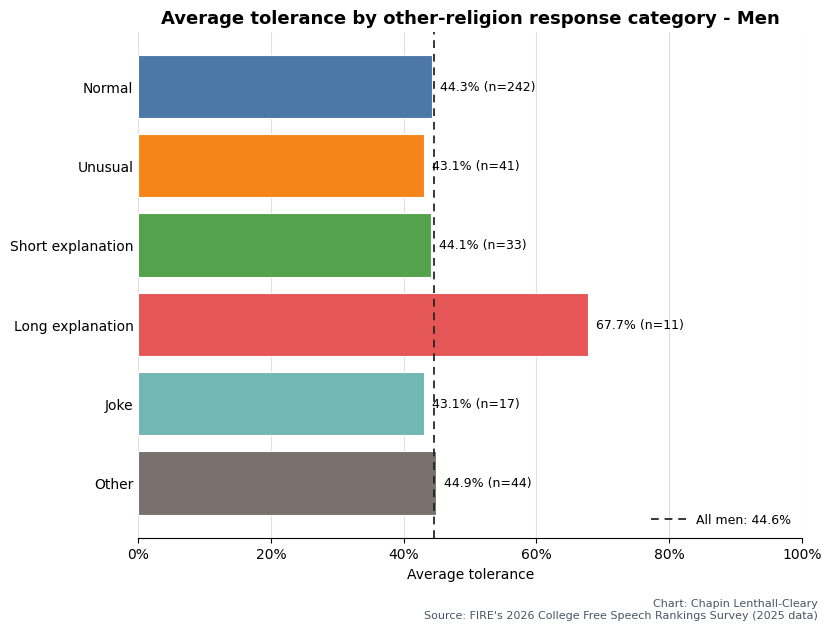

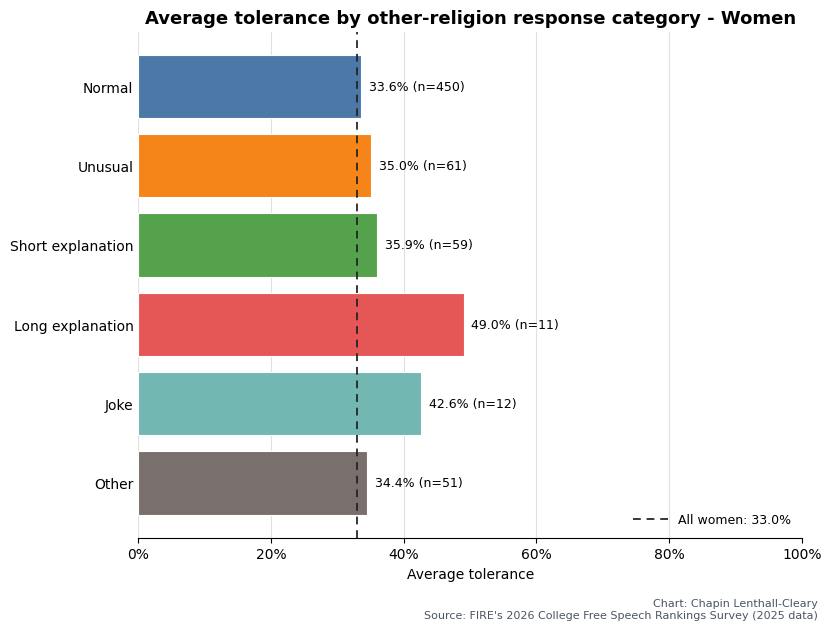

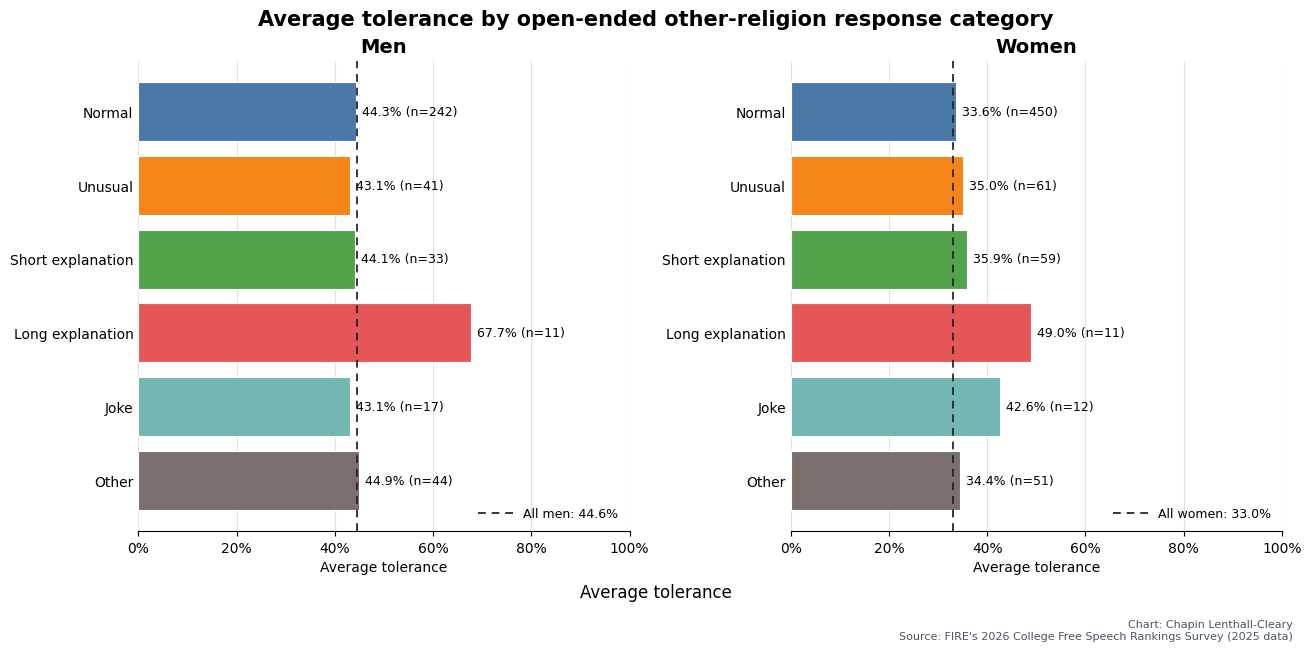

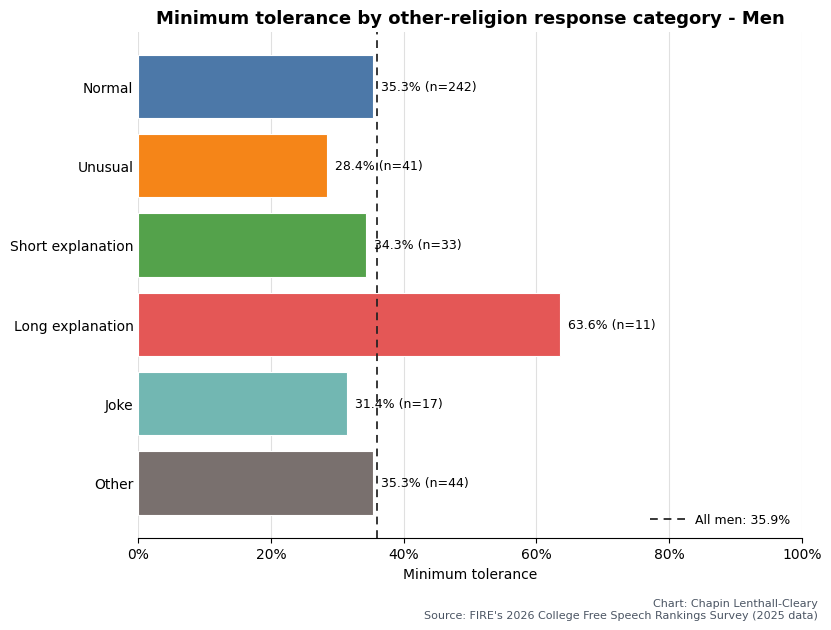

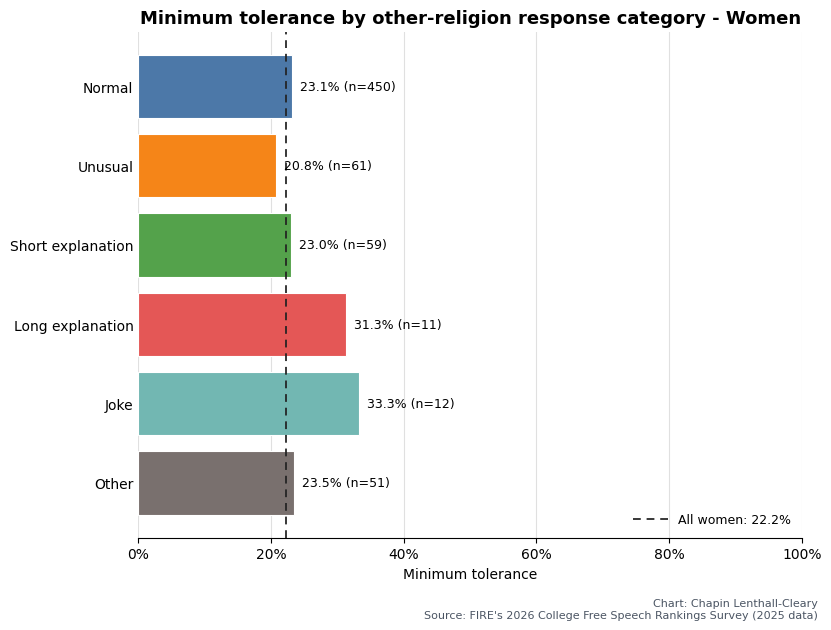

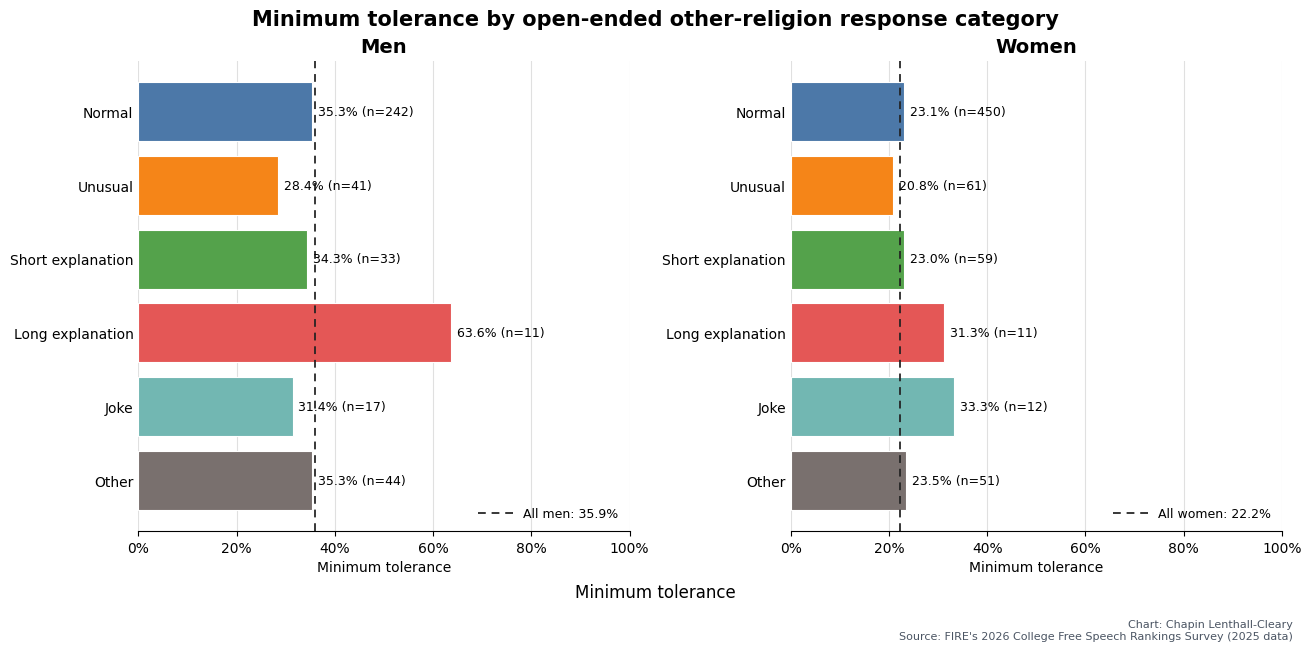

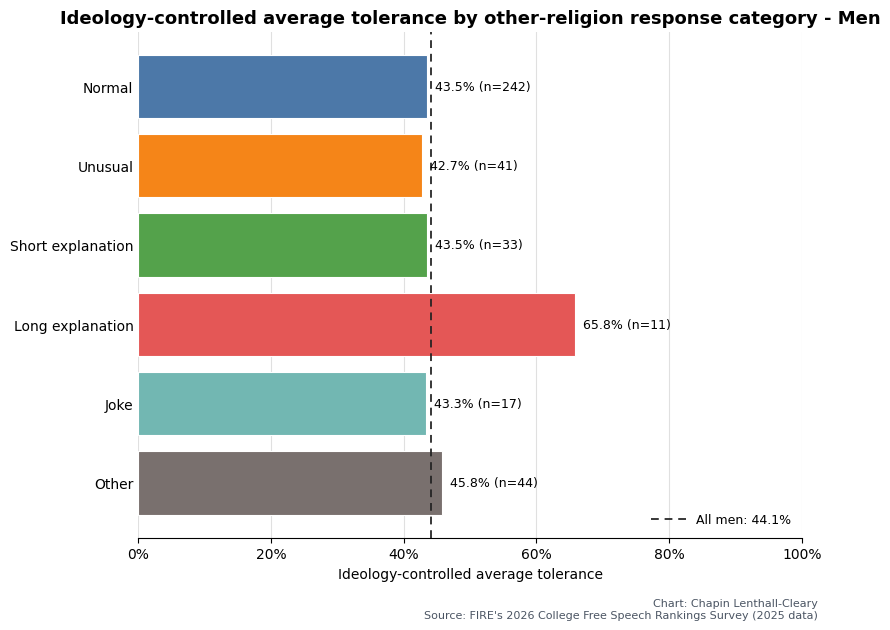

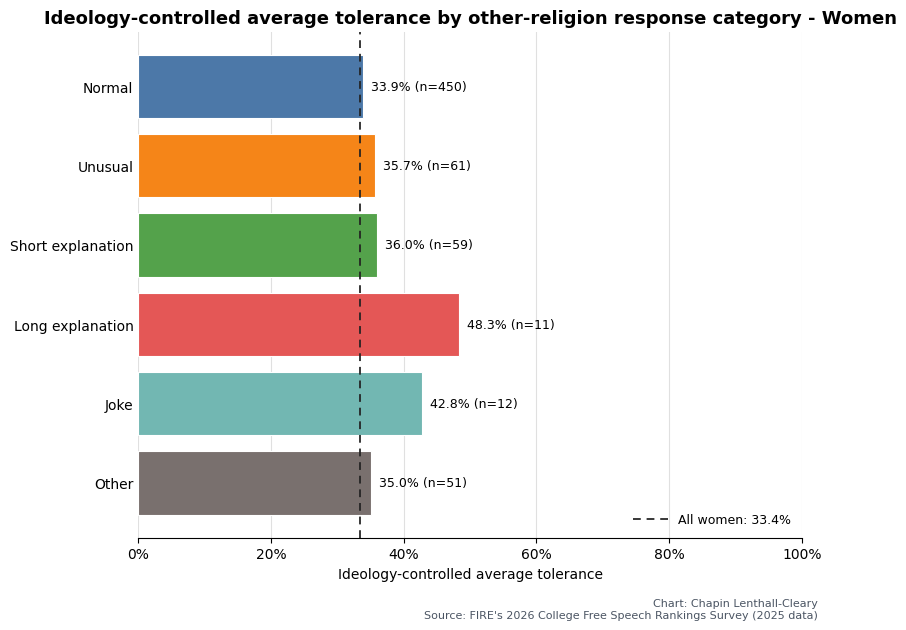

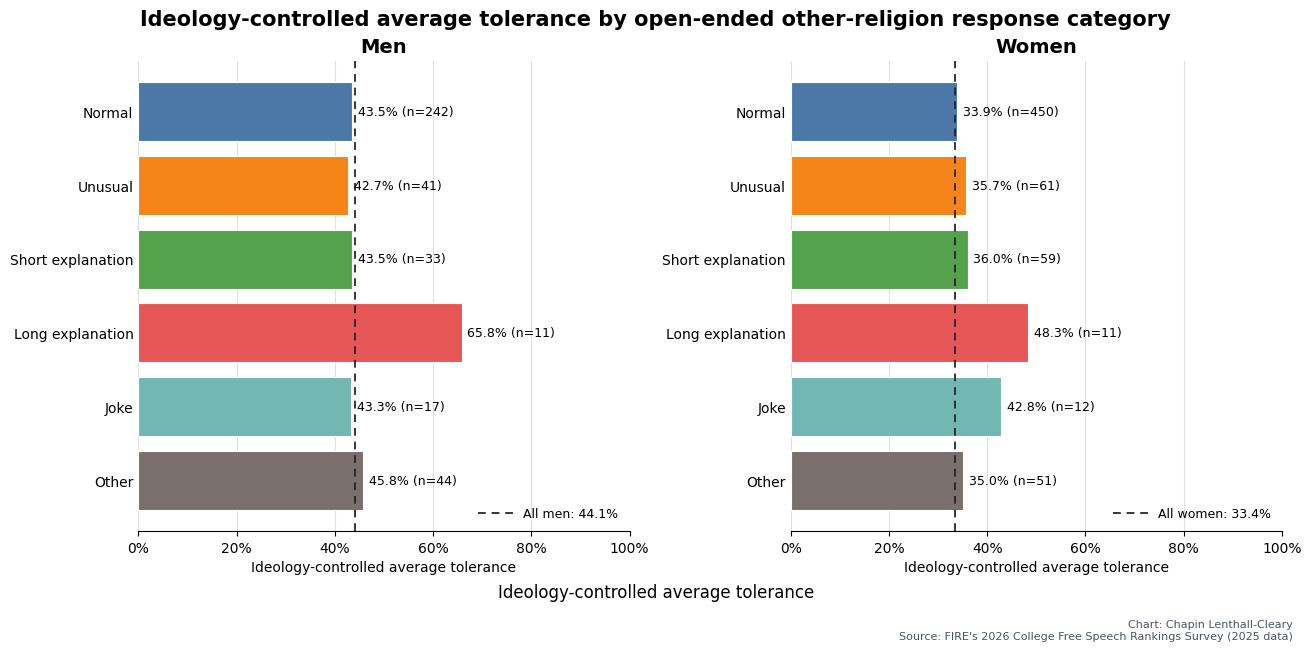

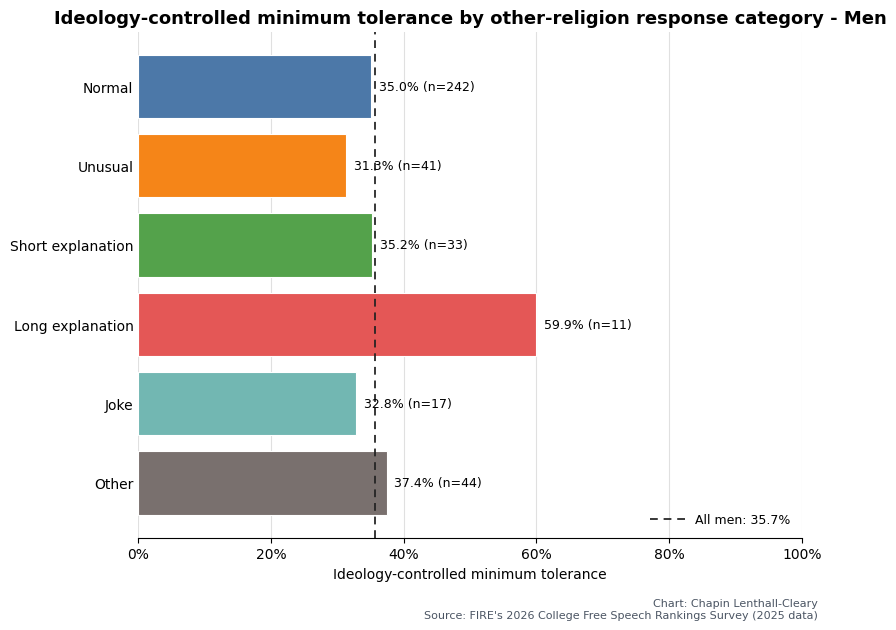

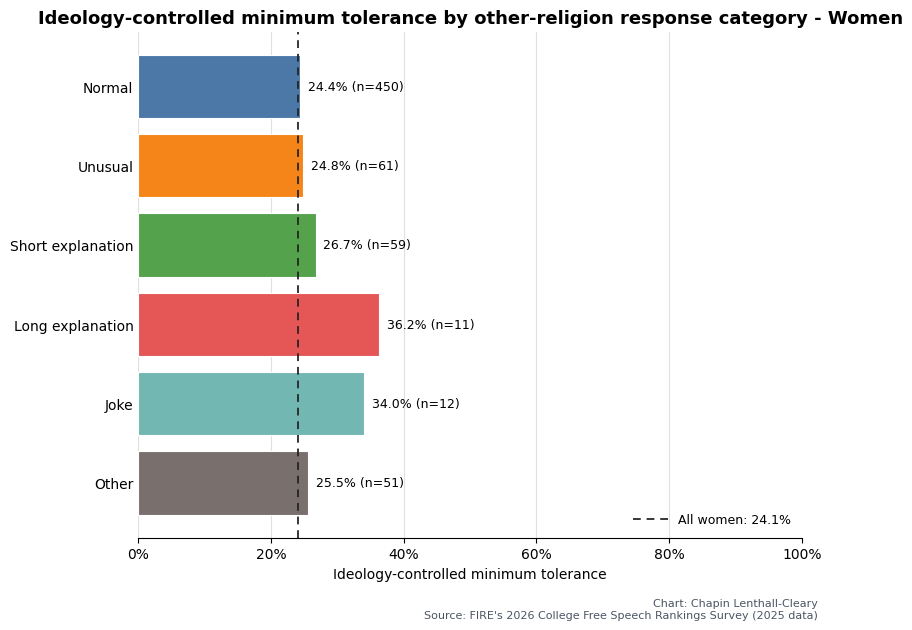

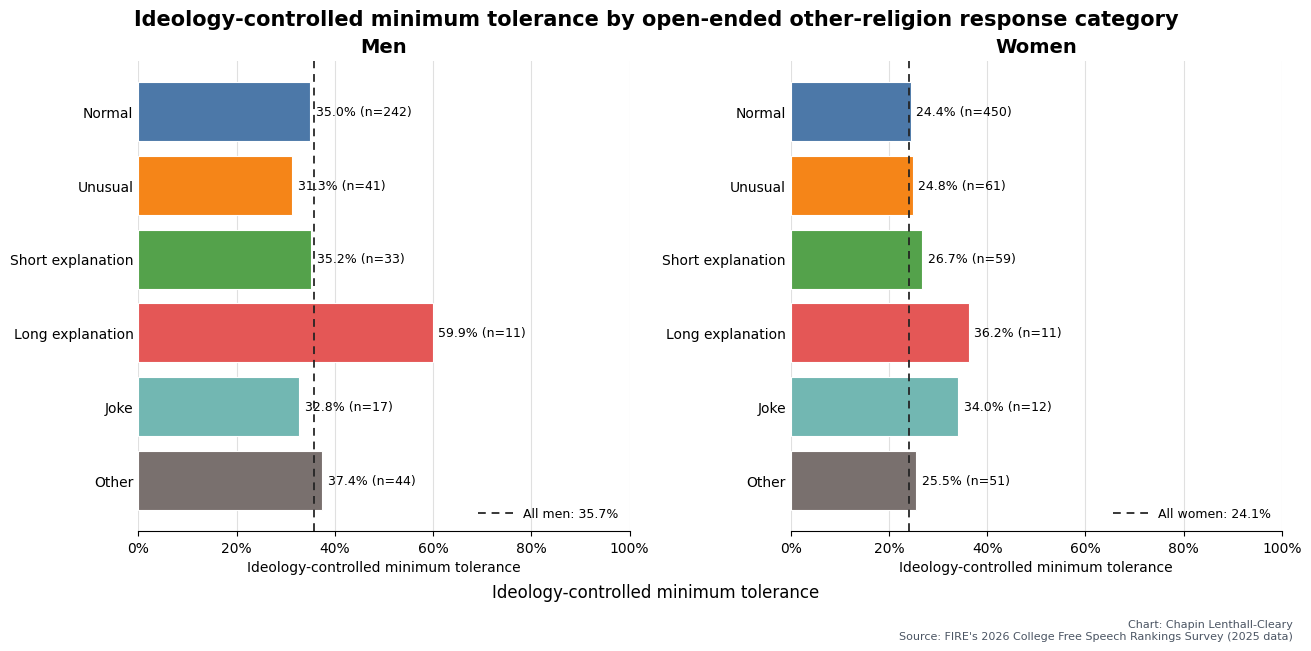

In [4]:
tag_lookup = load_tag_lookup()
full_survey = load_survey(DATA_PATH)
other_religion = build_other_religion_rows(full_survey, tag_lookup)

raw_tagged, counts_tagged = compute_count_tables(other_religion)
tag_summary = compute_tag_summary(other_religion)
overall_summary = compute_overall_by_gender(full_survey)
long_joke_table = compute_long_joke_table(other_religion)

raw_tagged.to_csv(OUT_RAW_TAGGED, index=False)
counts_tagged.to_csv(OUT_COUNTS_TAGGED, index=False)
tag_summary.to_csv(OUT_TAG_TOLERANCE, index=False)
overall_summary.to_csv(OUT_OVERALL_TOLERANCE, index=False)
long_joke_table.to_csv(OUT_LONG_JOKE, index=False)

for path in [OUT_RAW_TAGGED, OUT_COUNTS_TAGGED, OUT_TAG_TOLERANCE, OUT_OVERALL_TOLERANCE, OUT_LONG_JOKE]:
    print(f"Saved: {path.resolve()}")

print(f"Open-ended religion respondents tagged: {len(other_religion):,}")
display(tag_summary)
display(overall_summary)
display(long_joke_table)

for value_col, label in PLOT_SPECS:
    plot_tag_tolerance(tag_summary, overall_summary, value_col=value_col, label=label)
    plot_tag_tolerance_panel(tag_summary, overall_summary, value_col=value_col, label=label)
